In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt , tensorflow , keras
from tensorflow.keras import Sequential ,layers
from tensorflow.keras.layers import Dense , Flatten
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [3]:
(X_train,y_train),(X_test , y_test) = keras.datasets.mnist.load_data()

In [4]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


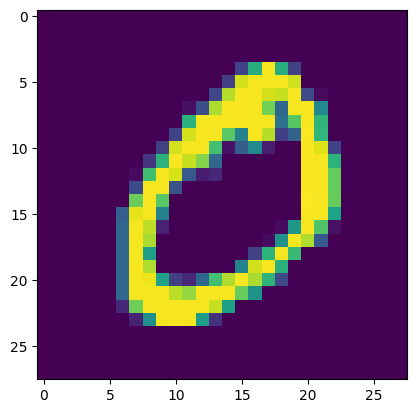

label :  0


In [5]:
plt.imshow(X_train[1])
plt.show()

print("label : ",y_train[1])

In [6]:
X_train_normalized = X_train/255
y_test_normalized = X_test/255

In [7]:
model = Sequential([
    layers.Conv2D(32 , (3,3) , activation = 'relu' , input_shape = (28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    Dense(128 , activation = 'relu'),
    Dense(10, activation="softmax")
])

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [9]:
model.fit(X_train_normalized , y_train , epochs = 10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.9550 - loss: 0.1517
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9841 - loss: 0.0520
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9900 - loss: 0.0320
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 523s 279ms/step - accuracy: 0.9936 - loss: 0.0207
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9955 - loss: 0.0142
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9968 - loss: 0.0102
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9975 - loss: 0.0073
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 22ms/step - accuracy: 0.9975 - loss: 0.0071
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9987 - loss: 0.0044
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9984 - loss: 0.0047


In [10]:
loss ,accuracy = model.evaluate(y_test_normalized , y_test)
print("Accuracy is:" , accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9878 - loss: 0.0528
Accuracy is: 0.9878000020980835


In [11]:
'''prediction = model.predict(X_test[:1])
print("predicted value from image:" , np.argmax(prediction))
print("actual value : " , y_test[0])'''

'prediction = model.predict(X_test[:1])\nprint("predicted value from image:" , np.argmax(prediction))\nprint("actual value : " , y_test[0])'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
predicted value: 7


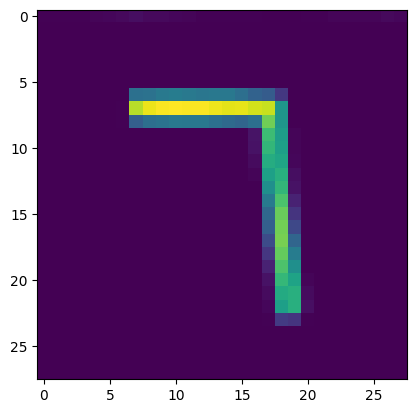

In [17]:

image_file_path = 'C:\\Users\\HP\\OneDrive\\Desktop\\DL_PROJECTS\\Digit_recognization\\image.png'
img = load_img(image_file_path, target_size=(28, 28),color_mode='grayscale')

plt.imshow(img)
img = img_to_array(img)
#img = img / 255.0

img = img.reshape(1, 28, 28)

prediction = model.predict(img)
print("predicted value:", np.argmax(prediction))

In [1]:
import mediapipe as mp
import cv2

In [5]:
cap = cv2.VideoCapture(0)

while True:
    success , img = cap.read()

    if not success:
        print("Camera not detected")
        break

    cv2.imshow("Webcam",img)

    key = cv2.waitKey(1)
    if key == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


In [8]:
import cv2
import mediapipe as mp

# Initialize MediaPipe Hand Detector
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.7
)

mp_draw = mp.solutions.drawing_utils

cap = cv2.VideoCapture(0)

while True:
    success, img = cap.read()

    if not success:
        break

    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Detect hands
    results = hands.process(img_rgb)

    # Draw landmarks
    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            mp_draw.draw_landmarks(
                img,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS
            )

    cv2.imshow("Hand Tracking", img)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

AttributeError: module 'mediapipe' has no attribute 'solutions'